# Oxford-IIIT Pet Superpixel Segmentation

This notebook contains the pipeline for segmentation based on superpixels. This approach aims to reduce the inference time of belief propagation on the full pixel graph, while potentially improving results. The idea is that the continuity enforced by the pairwise potential is more meaningful when applied to groups of pixels rather than individual ones.

In [2]:
import numpy as np
from sklearn.neural_network import MLPClassifier

import models
import inference
import utils
import visu
import data
import aggregation

In [3]:
category = 15

train_dataset, test_dataset = data.single_cat_OxfordIIITPet(category)

  0%|          | 0/3680 [00:00<?, ?it/s]

  0%|          | 0/3669 [00:00<?, ?it/s]

## Data exploration

You can go through the different image in the dataset by changing the variable `i`

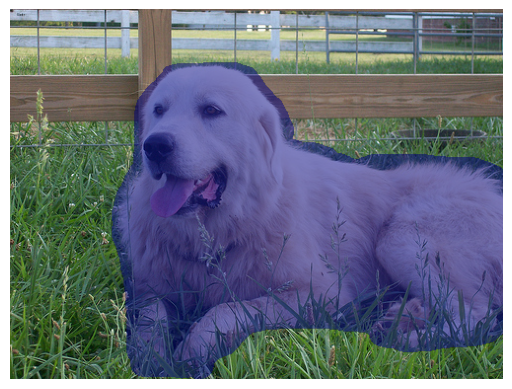

In [4]:
i = 0

image, (mask, cat) = train_dataset[i]
mask = utils.preprocess(mask)

visu.plot_mask(image, mask)

## Superpixel Visualization

Here is code to visualize the superpixels and the corresponding graph. The second graph shows the optimal mask possible with this method.

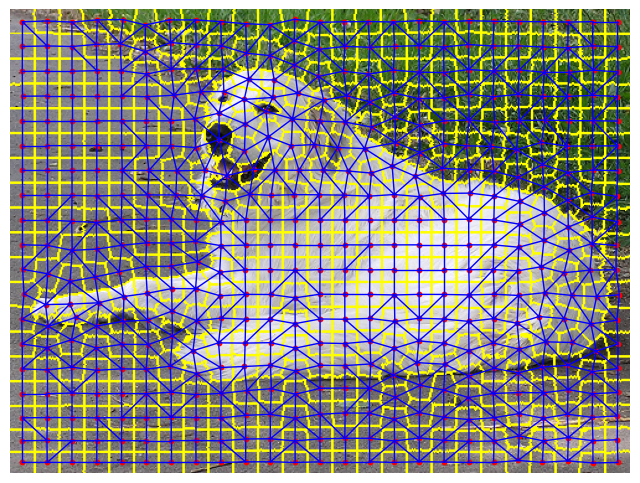

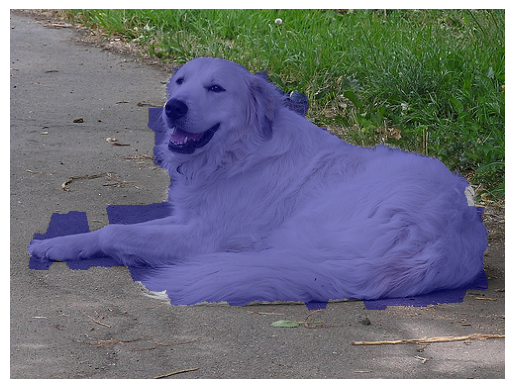

In [20]:
i = 0
n_segments=471
compactness=49

image, (mask, cat) = test_dataset[i]
image = np.array(image)
mask = np.array(utils.preprocess(mask))

segments, pixels, edges = utils.get_superpixels(image, n_segments=n_segments, compactness=compactness)

_, labels, super_mask = utils.process_super_pixel(image, mask, segments, pixels)
for i, p in enumerate(pixels):
    super_mask[segments == p] = labels[i]

visu.plot_superpixels(image, segments, edges)
visu.plot_mask(image, super_mask)

## Fit unary model

Here we us an MLP classifier to model the unary and use the color and variance of each superpixels as features.

In [21]:
sigma = 60.118431410215535
beta = 0.9195846711671256


agg_func = aggregation.lab_mean_var_agg

model = models.SuperSegment(MLPClassifier(hidden_layer_sizes=(16, 16), max_iter=1000), 
                                    agg_func=agg_func,
                                    beta=beta,
                                    sigma=sigma,
                                    compactness=compactness,
                                    n_segments=n_segments)


features, labels = utils.extract_super_features(train_dataset, n_segments, compactness, agg_func)
features, labels = utils.balance_data(features, labels)

model.fit(features, labels)

## Compute mean IOU on the validation set

This should output a mean IOU around $0.61$.

In [ ]:
max_iter = 100

ious = inference.sequential_segmentation(test_dataset, model, max_iter, trw=True)
print("Mean IoU:", ious.mean())

  0%|          | 0/100 [00:00<?, ?it/s]

## TRW-BP Visualization

Here you can visualize the result of trw-belief belief propagation with the model trained above.

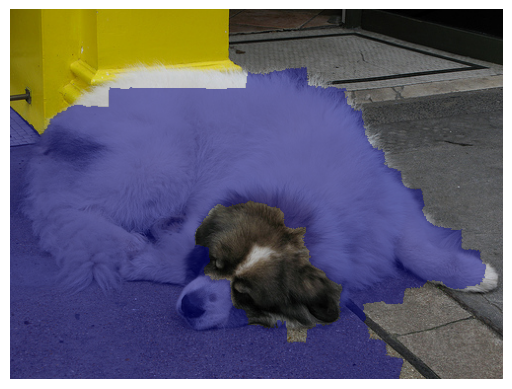

0.5741683805046844


In [ ]:
i = 0
max_iter = 100

image, (mask, cat) = test_dataset[i]
mask = utils.preprocess(mask)
image = np.array(image)

predictions = model(image, max_iter, trw=True)

    
visu.plot_mask(image, predictions)
print(utils.IoU(mask, predictions))